# **Guassian Mixture Model along with PAC on Olivetti Faces Dataset**

```
The classic Olivetti faces dataset contains 400 grayscale 64 × 64–
pixel images of faces. Each image is flattened to a 1D vector of
size 4,096. Forty different people were photographed (10 times
each), and the usual task is to train a model that can predict which
person is represented in each picture. Load the dataset using the
sklearn.datasets.fetch_olivetti_faces()
function, then split it into a training set, a validation set, and a test
set (note that the dataset is already scaled between 0 and 1). Since
the dataset is quite small, you will probably want to use stratified
sampling to ensure that there are the same number of images per
person in each set. Next, cluster the images using k-means, and
ensure that you have a good number of clusters (using one of the
techniques discussed in this chapter). Visualize the clusters: do you
see similar faces in each cluster?
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.metrics import f1_score, classification_report, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
 

In [2]:
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces()

X = faces.data
y = faces.target
images = faces.images


In [ ]:
import seaborn as sns


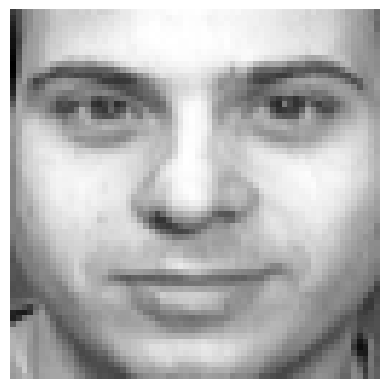

In [34]:
img = X[87].reshape(64, 64)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()


```
cluster the images using k-means, and
ensure that you have a good number of clusters (using one of the
techniques discussed in this chapter). Visualize the clusters: do you
see similar faces in each cluster?
the usual task is to train a model that can predict which
person is represented in each picture.

```

In [4]:
print(X.shape, y.shape)

(400, 4096) (400,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, y_train.shape)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(X_train.shape, X_val.shape)

(320, 4096) (320,)
(256, 4096) (64, 4096)


## **PCA** 

In [6]:
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

In [7]:
print(X_train.shape)
print(y_train.shape)
print(type(X_train))
print(type(y_train))
print(len(X_train))
print(len(y_train))

(256, 4096)
(256,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
256
256


In [8]:
from sklearn.cluster import KMeans

k = 40


kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)


In [9]:
kmeans.fit(X_train_pca)

KMeans(n_clusters=40, n_init=10, random_state=42)

In [10]:
train_clusters = kmeans.labels_
val_clusters = kmeans.predict(X_val_pca)
test_clusters = kmeans.predict(X_test_pca)

print(train_clusters[:10])

[12 17 35  8 23 19 24 26 10 16]


In [33]:
print(kmeans.cluster_centers_.shape)

(40, 100)


In [11]:
import numpy as np
from scipy.stats import mode
from sklearn.metrics import accuracy_score

In [12]:
cluster_to_label = np.zeros(40)

for i in range(40):
    mask = (train_clusters == i)
    if np.sum(mask) > 0:
        cluster_to_label[i] = mode(y_train[mask], keepdims=True).mode[0]

## **Convert clusters to predicted labels**

In [13]:
train_pred = cluster_to_label[train_clusters]
val_pred = cluster_to_label[val_clusters]
test_pred = cluster_to_label[test_clusters]

In [14]:
train_acc = accuracy_score(y_train, train_pred)
val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.671875
Validation Accuracy: 0.609375
Test Accuracy: 0.575


In [15]:
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture


gmm = GaussianMixture(
    n_components=40,
    covariance_type="full",
    random_state=42
)

gmm.fit(X_train_pca)

GaussianMixture(n_components=40, random_state=42)

In [16]:
train_clusters_gmm = gmm.predict(X_train_pca)
val_clusters_gmm = gmm.predict(X_val_pca)
test_clusters_gmm = gmm.predict(X_test_pca)

In [17]:
from sklearn.mixture import BayesianGaussianMixture

bgmm = BayesianGaussianMixture(
    n_components=80,   # upper bound
    covariance_type="full",
    random_state=42,
    weight_concentration_prior_type="dirichlet_process"
)

bgmm.fit(X_train_pca)

BayesianGaussianMixture(n_components=80, random_state=42)

In [18]:
train_clusters_bgmm = bgmm.predict(X_train_pca)
val_clusters_bgmm = bgmm.predict(X_val_pca)
test_clusters_bgmm = bgmm.predict(X_test_pca)

In [19]:
import numpy as np
from scipy.stats import mode
from sklearn.metrics import accuracy_score

In [20]:
def cluster_to_label_map(clusters, y_true, n_clusters):
    mapping = np.zeros(n_clusters)
    
    for i in range(n_clusters):
        mask = (clusters == i)
        if np.sum(mask) > 0:
            mapping[i] = mode(y_true[mask], keepdims=True).mode[0]
    
    return mapping

In [21]:
map_gmm = cluster_to_label_map(train_clusters_gmm, y_train, 40)

train_pred_gmm = map_gmm[train_clusters_gmm]
val_pred_gmm = map_gmm[val_clusters_gmm]
test_pred_gmm = map_gmm[test_clusters_gmm]

print("GMM Results:")
print("Train:", accuracy_score(y_train, train_pred_gmm))
print("Val:", accuracy_score(y_val, val_pred_gmm))
print("Test:", accuracy_score(y_test, test_pred_gmm))

GMM Results:
Train: 0.62890625
Val: 0.5625
Test: 0.55


In [22]:
map_bgmm = cluster_to_label_map(train_clusters_bgmm, y_train, 80)

train_pred_bgmm = map_bgmm[train_clusters_bgmm]
val_pred_bgmm = map_bgmm[val_clusters_bgmm]
test_pred_bgmm = map_bgmm[test_clusters_bgmm]

print("Bayesian GMM Results:")
print("Train:", accuracy_score(y_train, train_pred_bgmm))
print("Val:", accuracy_score(y_val, val_pred_bgmm))
print("Test:", accuracy_score(y_test, test_pred_bgmm))

Bayesian GMM Results:
Train: 0.87109375
Val: 0.765625
Test: 0.7875
